График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/wss.png


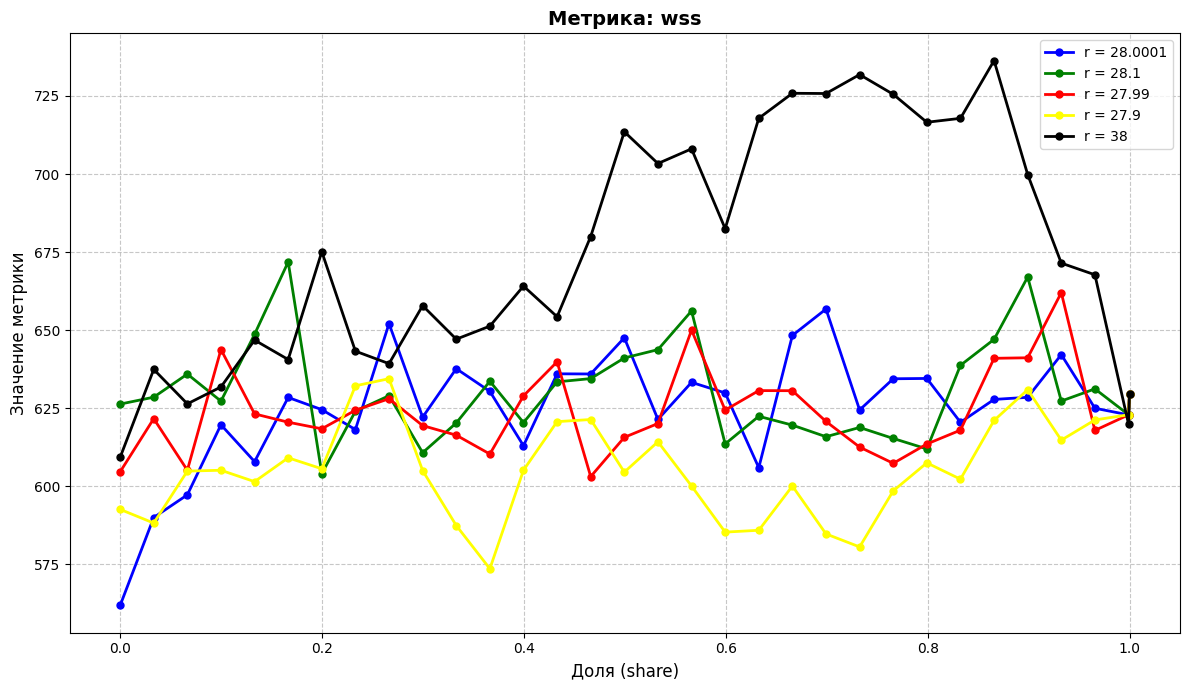

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/r2.png


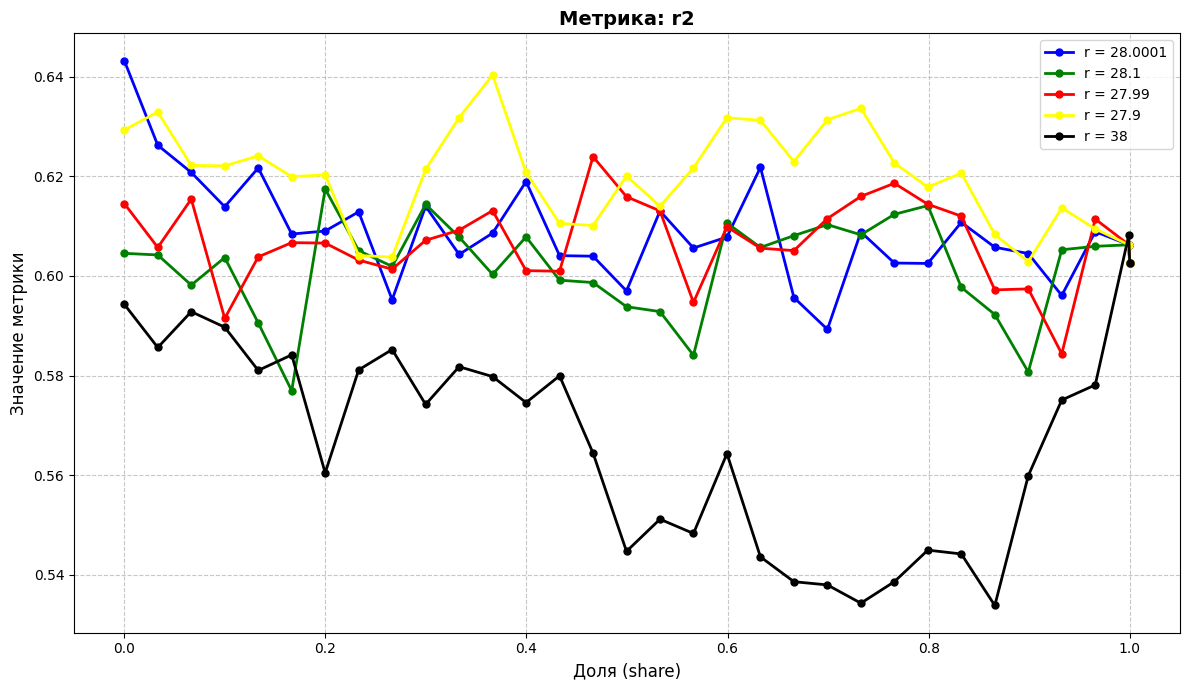

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/calinski_harabasz.png


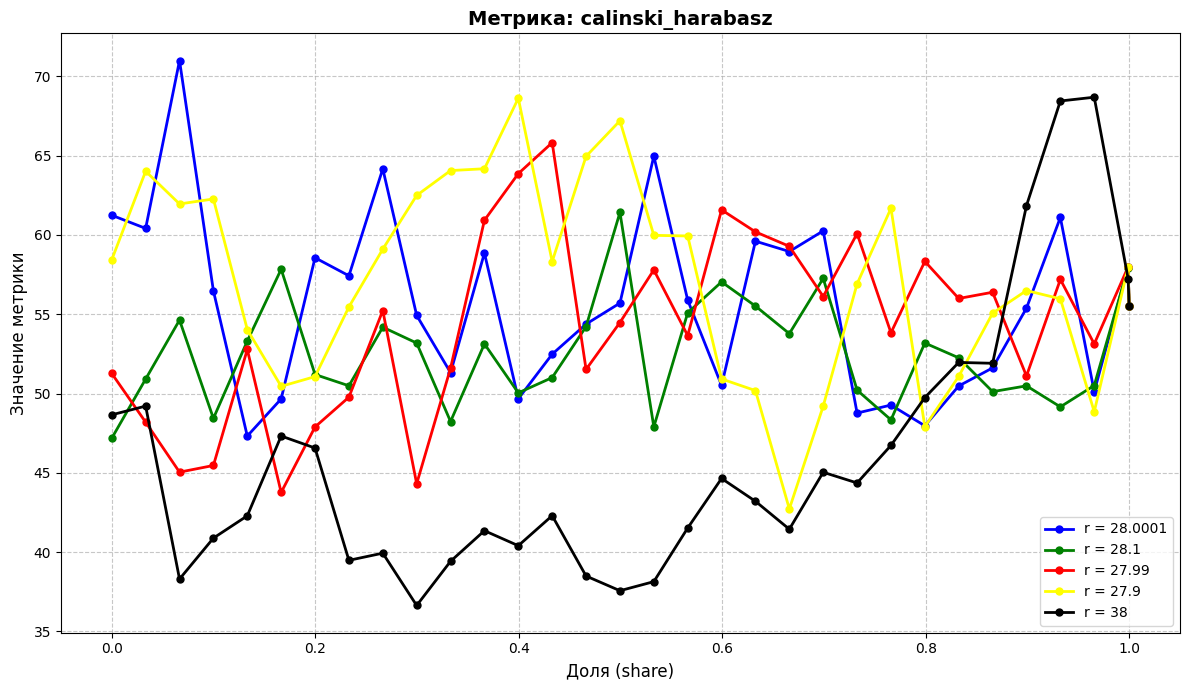

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/xie_beni.png


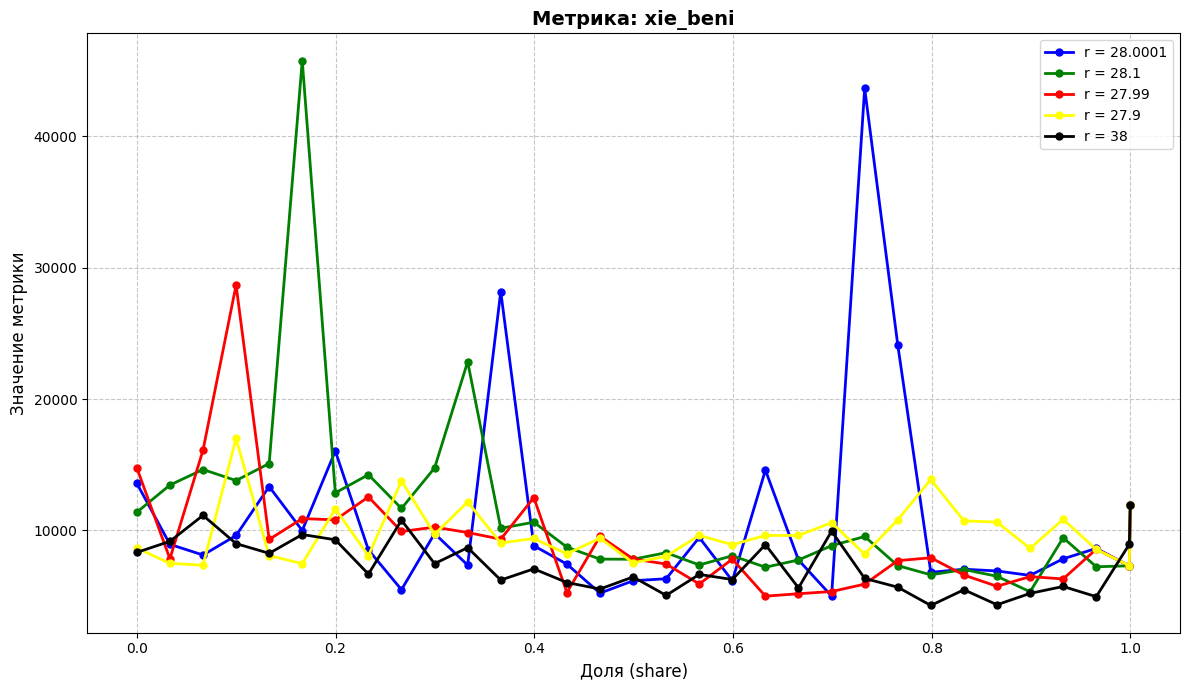

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/davies_bouldin.png


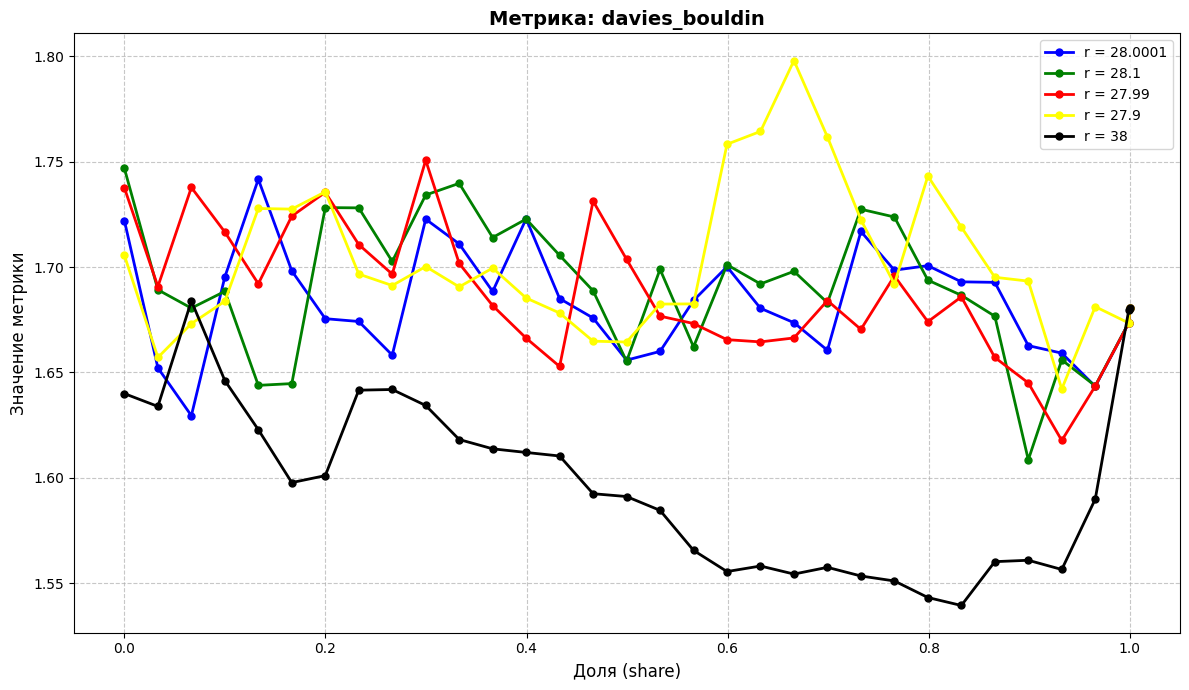

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/noise_percentage.png


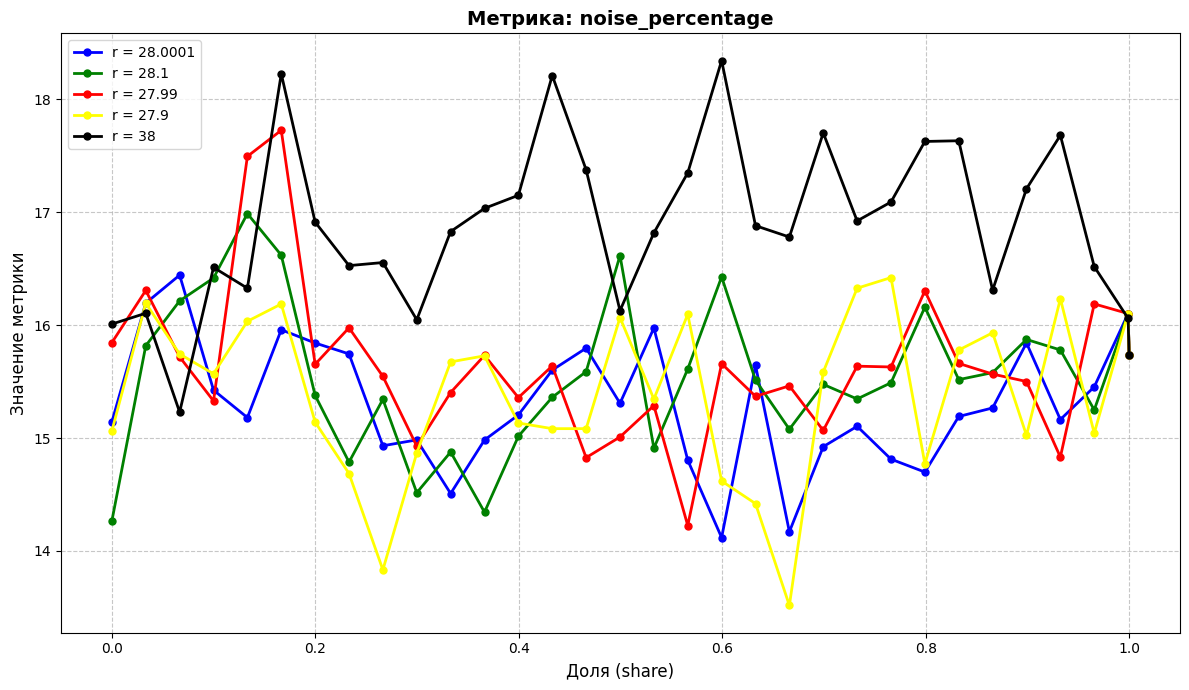

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/avg_cluster_size.png


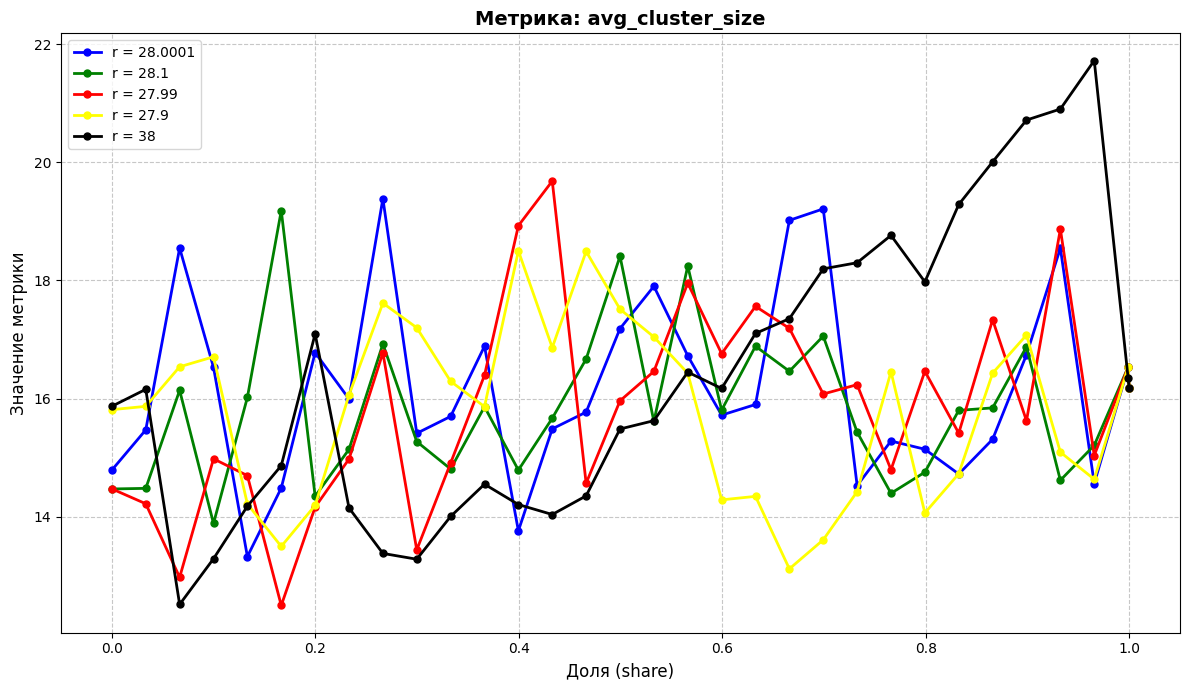

In [4]:
import matplotlib.pyplot as plt
import numpy as np

import os

def plot_metric_results(filename, metric_name=None, show=True, save=True):
    """
    Визуализирует результаты метрик из файла

    Параметры:
    filename (str): путь к файлу с данными
    metric_name (str): название метрики для заголовка
    show (bool): показывать график на экране
    save (bool): сохранять график в файл
    """
    # Проверка существования файла
    if not os.path.exists(filename):
        print(f"Файл не найден: {filename}")
        return

    # Чтение данных из файла
    with open(filename, 'r') as f:
        content = f.read().strip()

    # Разделение на блоки данных
    blocks = content.split("share,metric_value\n")[1:]

    # Проверка количества блоков
    if len(blocks) != 5:
        print(f"Неверный формат данных в файле {filename}. Ожидается 5 блока.")
        return

    # Параметры отклонений
    deviations = [0.0001, 0.1, -0.01, -0.1, 10]
    colors = ['blue', 'green', 'red','yellow','black']

    # Создание графика
    plt.figure(figsize=(12, 7))

    for i, block in enumerate(blocks):
        # Обработка каждого блока данных
        lines = block.strip().split('\n')
        shares = []
        values = []

        for line in lines:
            # Пропуск пустых строк
            if not line.strip():
                continue
            try:
                s, v = line.split(',')
                shares.append(float(s))
                values.append(float(v))
            except ValueError:
                print(f"Ошибка формата в строке: {line}")
                continue

        # Сортировка по значению share
        sorted_data = sorted(zip(shares, values))
        shares_sorted, values_sorted = zip(*sorted_data)

        # Построение графика для текущего отклонения
        plt.plot(shares_sorted, values_sorted,
                 color=colors[i],
                 marker='o', markersize=5, linewidth=2,
                 label=f'r = {28+deviations[i]}')

    # Настройки графика
    title = f'Метрика: {metric_name}' if metric_name else 'Сравнение метрик'
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Доля (share)', fontsize=12)
    plt.ylabel('Значение метрики', fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.tight_layout()

    # Сохранение графика
    if save:
        output_filename = filename.replace('.txt', '.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        print(f"График сохранён как: {output_filename}")

    # Показ графика
    if show:
        plt.show()
    else:
        plt.close()


# Пример использования:
if __name__ == "__main__":
    # Для каждой метрики вызываем функцию
    metrics = [
        "wss",
        "r2",
        "calinski_harabasz",
        "xie_beni",
        "davies_bouldin",
        "noise_percentage",
        "avg_cluster_size"
    ]

    for metric in metrics:
        filename = f"/home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/{metric}.txt"
        plot_metric_results(filename, metric)
